In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
nadia = cv2.imread('../DATA/Nadia_Murad.jpg')
denis = cv2.imread('../DATA/Denis_Mukwege.jpg')
solvay = cv2.imread('../DATA/solvay_conference.jpg')

In [3]:
# load pretrained cascade classifiers
face_cascade = cv2.CascadeClassifier('../DATA/haarcascades/haarcascade_frontalface_default.xml')

In [4]:
def detect_face(img):
    face_img = img.copy()
    face_rects = face_cascade.detectMultiScale(face_img)
    for (x,y,w,h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 10)
    return face_img

In [5]:
result = detect_face(denis)

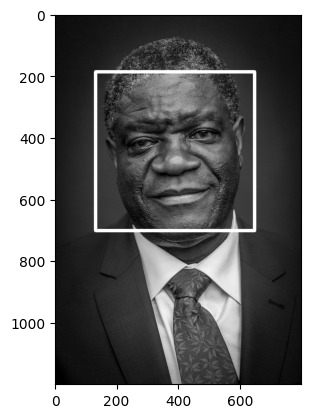

In [6]:
plt.imshow(result, cmap='gray')


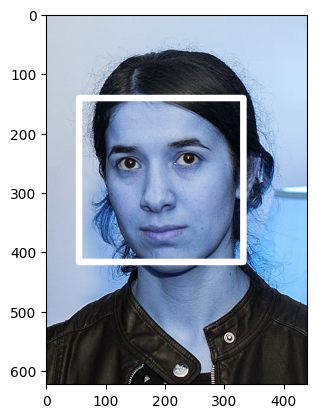

In [7]:
result = detect_face(nadia)
plt.imshow(result, cmap='gray')

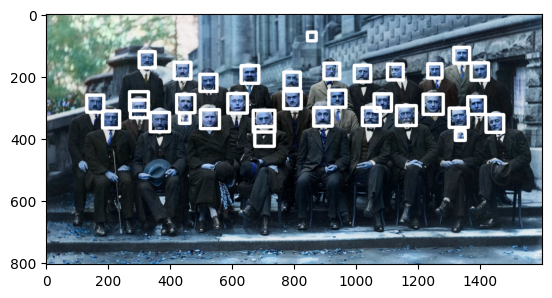

In [8]:
result = detect_face(solvay)
plt.imshow(result, cmap='gray')

In [9]:
def adj_detect_face(img):
    face_img = img.copy()
    face_rects = face_cascade.detectMultiScale(face_img, scaleFactor=1.2, minNeighbors=5)
    for (x,y,w,h) in face_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 10)
    return face_img

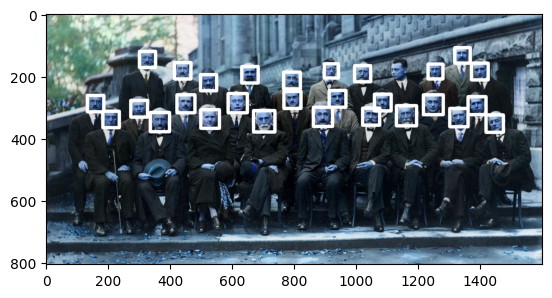

In [10]:
result = adj_detect_face(solvay)
plt.imshow(result, cmap='gray')

In [11]:
eye_cascade = cv2.CascadeClassifier('../DATA/haarcascades/haarcascade_eye.xml')
def detect_eyes(img):
    face_img = img.copy()
    eye_rects = eye_cascade.detectMultiScale(face_img, scaleFactor=1.1, minNeighbors=5)
    for (x,y,w,h) in eye_rects:
        cv2.rectangle(face_img, (x,y), (x+w,y+h), (255,255,255), 10)
    return face_img

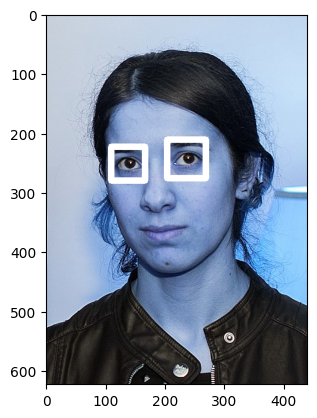

In [12]:
result = detect_eyes(nadia)
plt.imshow(result, cmap='gray')

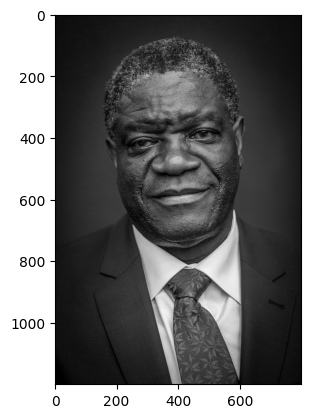

In [13]:
result = detect_eyes(denis)
# it does not work bc contrast, glow around head, and skin tone very similar to eye blank tone
plt.imshow(result, cmap='gray')

In [ ]:
# try on video
cap = cv2.VideoCapture(0)
while True:
    ret, frame = cap.read(0)
    frame = detect_face(frame)
    cv2.imshow('face detection', frame)
    k = cv2.waitKey(1)
    if k == 27:
        break
cap.release()
cv2.destroyAllWindows()